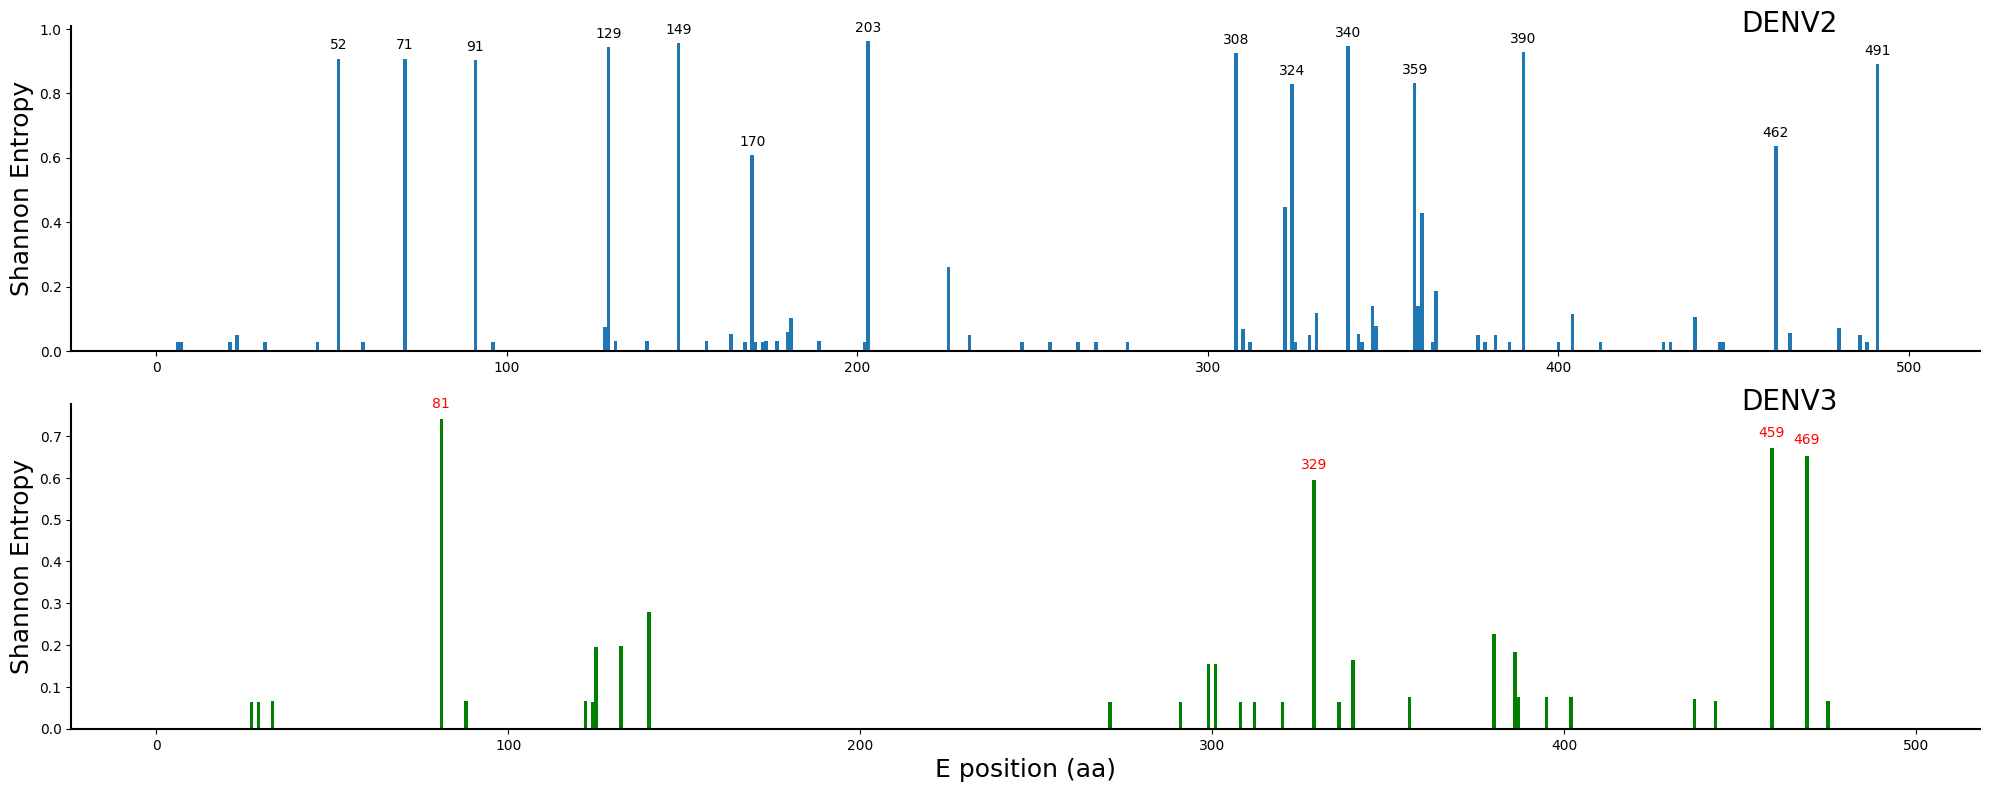

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import math

def load_alignment(path):
    sequences = []
    with open(path) as f:
        seq = ""
        for line in f:
            if line.startswith(">"):
                if seq:
                    sequences.append(seq)
                seq = ""
            else:
                seq += line.strip()
        if seq:
            sequences.append(seq)
    return sequences

def compute_entropy(sequences):
    seqs = np.array([list(s) for s in sequences])
    _, L = seqs.shape
    ent = []
    for i in range(L):
        col = seqs[:, i]
        counts = {}
        for aa in col:
            if aa in ("-", "X"):
                continue
            counts[aa] = counts.get(aa, 0) + 1
        total = sum(counts.values())
        h = 0.0
        for c in counts.values():
            p = c / total
            h -= p * math.log2(p)
        ent.append(h)
    return ent

ent2 = compute_entropy(load_alignment("../Data/D2/Col_only/nextclade.cds_translation.E.fasta"))
ent3 = compute_entropy(load_alignment("../Data/D3/D3gisaid_arbo_2025_04_24_18/nextclade.cds_translation_Colombia.E.fasta"))

threshold = 0.55

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8), sharex=False)

# DENV2
x2 = np.arange(1, len(ent2) + 1)
ax1.bar(x2, ent2, width=1.0)
high2 = [i for i, h in enumerate(ent2, start=1) if h > threshold]
for pos in high2:
    ax1.text(pos, ent2[pos-1] + 0.02, str(pos),
             ha="center", va="bottom", color="k", fontsize=10)
ax1.set_ylabel("Shannon Entropy", size=18)
ax1.text(0.9, 1.05, "DENV2", size=20, ha="center", va="top", transform=ax1.transAxes)
for loc in ("top","right"):
    ax1.spines[loc].set_visible(False)
for loc in ("left","bottom"):
    ax1.spines[loc].set_linewidth(1.5)

# DENV3
x3 = np.arange(1, len(ent3) + 1)
ax2.bar(x3, ent3, width=1.0, color="green")
high3 = [i for i, h in enumerate(ent3, start=1) if h > threshold]
for pos in high3:
    ax2.text(pos, ent3[pos-1] + 0.02, str(pos),
             ha="center", va="bottom", color="red", fontsize=10)
ax2.set_xlabel("E position (aa)", size=18)
ax2.set_ylabel("Shannon Entropy", size=18)
ax2.text(0.9, 1.05, "DENV3", size=20, ha="center", va="top", transform=ax2.transAxes)
for loc in ("top","right"):
    ax2.spines[loc].set_visible(False)
for loc in ("left","bottom"):
    ax2.spines[loc].set_linewidth(1.5)

plt.tight_layout()
plt.savefig("../Figures/entropy_plot_d3d2.png", dpi=1200)
plt.show()